In [1]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import scanpy as sc
import episcanpy as epi
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

import glob
import os

from pathlib import Path
from scipy import io
from helps import *

# Raw CM

## GEX & ADT

In [ ]:
adata=sc.read_h5ad("Datasets/BMMCCite/RawFiles/GSE194122_openproblems_neurips2021_cite_BMMC_processed.h5ad")
adata

In [ ]:
adata = adata[adata.obs["Samplename"] == "site1_donor1_cite"]
adata

In [ ]:
rna = adata[:, adata.var["feature_types"] == "GEX"].copy()
adt = adata[:, adata.var["feature_types"] == "ADT"].copy()

rna.obs["CellType"] = rna.obs["cell_type"]
adt.obs["CellType"] = adt.obs["cell_type"]

rna.X=rna.layers["counts"]
adt.X=adt.layers["counts"]

In [ ]:
sc.pp.scrublet(rna)

In [ ]:
Path("Datasets/BMMCCite/CM/").mkdir(parents=True, exist_ok=True)
rna.write("Datasets/BMMCCite/CM/BMMCCite_GEX_Raw.h5ad", compression="gzip")
adt.write("Datasets/BMMCCite/CM/BMMCCite_ADT_Raw.h5ad", compression="gzip")

## mRNA & lncRNA

In [13]:
adata=sc.read_h5ad("Datasets/BMMCCite/CM/BMMCCite_GEX_Raw.h5ad")
adata.var.head()

,feature_types,gene_id
AL627309.5,GEX,ENSG00000241860
LINC01409,GEX,ENSG00000237491
LINC01128,GEX,ENSG00000228794
LINC00115,GEX,ENSG00000225880
FAM41C,GEX,ENSG00000230368


In [14]:
names = ["chr", "source", "type", "start", "stop", "score", "strand", "frame", "attribute"]
gtf_file="../AnnotRef/hs/hg38/gencode.v44.annotation.gtf.gz"
gtf=pd.read_csv(gtf_file, sep="\t", header=None, comment="#", names=names, dtype={"chr": str})
gtf=gtf[(gtf["type"]=="gene") & (gtf["source"]=="HAVANA")]

gene_names=[attr.replace("gene_name", "").strip().strip("\"") for feature_attr in gtf.attribute for attr in feature_attr.split(";") if attr.strip().startswith("gene_name")]
tmp = [attr.replace("gene_type", "").strip().strip("\"") for feature_attr in gtf.attribute for attr in feature_attr.split(";") if attr.strip().startswith("gene_type ")]
if not tmp:
    tmp = [attr.replace("gene_biotype", "").strip().strip("\"") for feature_attr in gtf.attribute for attr in feature_attr.split(";") if attr.strip().startswith("gene_biotype ")]

info=pd.DataFrame(data=[gene_names,tmp], index=["GeneName","GeneType"]).T
info.head()

,GeneName,GeneType
0,DDX11L2,lncRNA
1,DDX11L1,transcribed_unprocessed_pseudogene
2,WASH7P,unprocessed_pseudogene
3,MIR1302-2HG,lncRNA
4,FAM138A,lncRNA


In [15]:
mRNA=adata[:, intersection([adata.var.index, info[info["GeneType"]=="protein_coding"]["GeneName"]])]
print(mRNA.shape)
mRNA.write("Datasets/BMMCCite/CM/BMMCCite_mRNA_Raw.h5ad", compression="gzip")

(5227, 11700)


In [16]:
lncRNA=adata[:, intersection([adata.var.index, info[info["GeneType"]=="lncRNA"]["GeneName"]])]
print(lncRNA.shape)
lncRNA.write("Datasets/BMMCCite/CM/BMMCCite_lncRNA_Raw.h5ad", compression="gzip")

(5227, 686)


# Processing

## GEX

In [6]:
adata=sc.read_h5ad("Datasets/BMMCCite/CM/BMMCCite_GEX_Raw.h5ad")
adata.layers["raw"]=scipy.sparse.csr_matrix(adata.X.copy())
del adata.layers["counts"]
adata

AnnData object with n_obs × n_vars = 5227 × 13953
    obs: 'GEX_n_genes_by_counts', 'GEX_pct_counts_mt', 'GEX_size_factors', 'GEX_phase', 'ADT_n_antibodies_by_counts', 'ADT_total_counts', 'ADT_iso_count', 'cell_type', 'batch', 'ADT_pseudotime_order', 'GEX_pseudotime_order', 'Samplename', 'Site', 'DonorNumber', 'Modality', 'VendorLot', 'DonorID', 'DonorAge', 'DonorBMI', 'DonorBloodType', 'DonorRace', 'Ethnicity', 'DonorGender', 'QCMeds', 'DonorSmoker', 'is_train', 'CellType', 'doublet_score', 'predicted_doublet'
    var: 'feature_types', 'gene_id'
    uns: 'dataset_id', 'genome', 'organism', 'scrublet'
    obsm: 'ADT_X_pca', 'ADT_X_umap', 'ADT_isotype_controls', 'GEX_X_pca', 'GEX_X_umap'
    layers: 'raw'

In [21]:
epi.pp.qc_stats(adata, verbose=False)
mt_gene_mask = np.flatnonzero([gene.startswith(("MT","mt")) for gene in adata.var.index])
adata.obs['mt_frac'] = np.sum(adata[:, mt_gene_mask].X, axis=1).A1/adata.obs['n_counts']

In [22]:
min_features = 10**np.quantile(adata.obs["log_n_features"], 0.05)
max_features = 10**np.quantile(adata.obs["log_n_features"], 0.95)
min_cells = 10**np.quantile(adata.var["log_n_cells"], 0.05)
max_cells = 10**np.quantile(adata.var["log_n_cells"], 0.95)

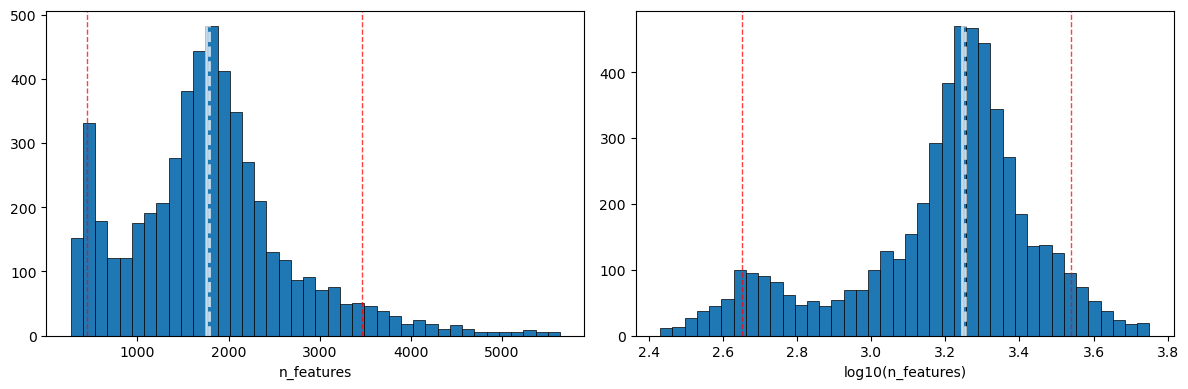

Max:	5637
Median:	1756.0
Mean:	1789.5833173904725
Min:	269


In [23]:
epi.pl.histogram(adata, "n_features", min_threshold=min_features, max_threshold=max_features, show_log=True)

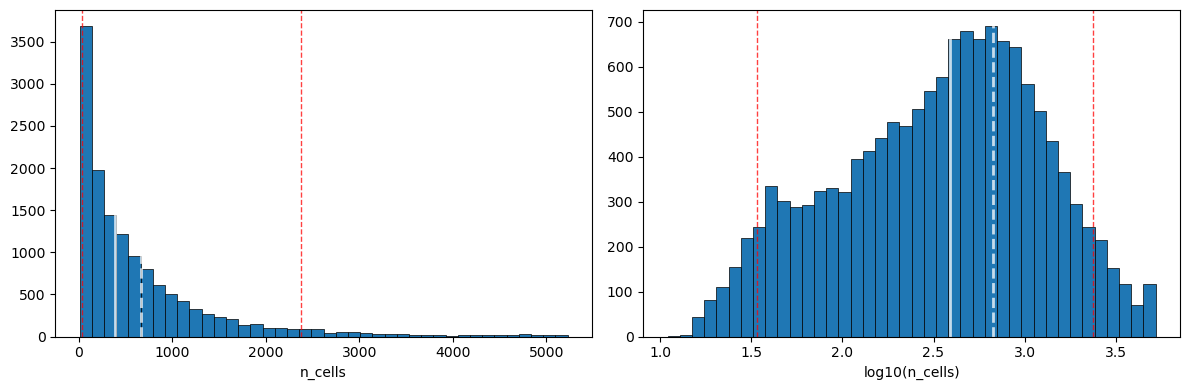

Max:	5227
Median:	390.0
Mean:	670.4043574858454
Min:	11


In [24]:
epi.pl.histogram(adata, "n_cells", min_threshold=min_cells, max_threshold=max_cells, show_log=True)

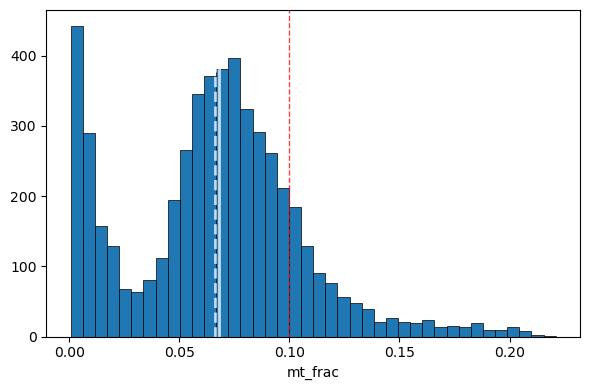

Max:	0.2209802269935608
Median:	0.06809931993484497
Mean:	0.06633108109235764
Min:	0.000665557396132499


In [25]:
epi.pl.histogram(adata, "mt_frac", max_threshold=0.1, show_log=False)

In [26]:
epi.pp.set_filter(adata, "n_features", min_threshold=min_features, max_threshold=max_features, verbose=False)
epi.pp.set_filter(adata, "n_cells", min_threshold=min_cells, max_threshold=max_cells, verbose=False)
adata = epi.pp.apply_filters(adata, verbose=False)
adata = adata[adata.obs["mt_frac"]<=0.1]
adata=adata[adata.obs.predicted_doublet==False]
adata

View of AnnData object with n_obs × n_vars = 3890 × 12606
    obs: 'GEX_n_genes_by_counts', 'GEX_pct_counts_mt', 'GEX_size_factors', 'GEX_phase', 'ADT_n_antibodies_by_counts', 'ADT_total_counts', 'ADT_iso_count', 'cell_type', 'batch', 'ADT_pseudotime_order', 'GEX_pseudotime_order', 'Samplename', 'Site', 'DonorNumber', 'Modality', 'VendorLot', 'DonorID', 'DonorAge', 'DonorBMI', 'DonorBloodType', 'DonorRace', 'Ethnicity', 'DonorGender', 'QCMeds', 'DonorSmoker', 'is_train', 'CellType', 'doublet_score', 'predicted_doublet', 'n_features', 'log_n_features', 'n_counts', 'log_n_counts', 'mt_frac', 'passes_filter'
    var: 'feature_types', 'gene_id', 'n_cells', 'log_n_cells', 'passes_filter'
    uns: 'dataset_id', 'genome', 'organism', 'scrublet'
    obsm: 'ADT_X_pca', 'ADT_X_umap', 'ADT_isotype_controls', 'GEX_X_pca', 'GEX_X_umap'
    layers: 'counts'

In [27]:
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)

In [28]:
sc.pp.highly_variable_genes(adata, flavor='seurat_v3')
min_var = np.quantile(adata.var.variances_norm, 0.7)
adata=adata[:, adata.var.variances_norm>min_var]
adata = adata[:, adata.X.max(axis=0)>0]
adata = adata[adata.X.max(axis=1)>0]
adata

View of AnnData object with n_obs × n_vars = 3890 × 3782
    obs: 'GEX_n_genes_by_counts', 'GEX_pct_counts_mt', 'GEX_size_factors', 'GEX_phase', 'ADT_n_antibodies_by_counts', 'ADT_total_counts', 'ADT_iso_count', 'cell_type', 'batch', 'ADT_pseudotime_order', 'GEX_pseudotime_order', 'Samplename', 'Site', 'DonorNumber', 'Modality', 'VendorLot', 'DonorID', 'DonorAge', 'DonorBMI', 'DonorBloodType', 'DonorRace', 'Ethnicity', 'DonorGender', 'QCMeds', 'DonorSmoker', 'is_train', 'CellType', 'doublet_score', 'predicted_doublet', 'n_features', 'log_n_features', 'n_counts', 'log_n_counts', 'mt_frac', 'passes_filter'
    var: 'feature_types', 'gene_id', 'n_cells', 'log_n_cells', 'passes_filter', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'dataset_id', 'genome', 'organism', 'scrublet', 'log1p', 'hvg'
    obsm: 'ADT_X_pca', 'ADT_X_umap', 'ADT_isotype_controls', 'GEX_X_pca', 'GEX_X_umap'
    layers: 'counts'

In [29]:
adata.write("Datasets/BMMCCite/CM/BMMCCite_GEX_Def.h5ad", compression="gzip")

## mRNA

In [7]:
adata=sc.read_h5ad("Datasets/BMMCCite/CM/BMMCCite_mRNA_Raw.h5ad")
adata.layers["raw"]=scipy.sparse.csr_matrix(adata.X.copy())
del adata.layers["counts"]
adata

AnnData object with n_obs × n_vars = 5227 × 11700
    obs: 'GEX_n_genes_by_counts', 'GEX_pct_counts_mt', 'GEX_size_factors', 'GEX_phase', 'ADT_n_antibodies_by_counts', 'ADT_total_counts', 'ADT_iso_count', 'cell_type', 'batch', 'ADT_pseudotime_order', 'GEX_pseudotime_order', 'Samplename', 'Site', 'DonorNumber', 'Modality', 'VendorLot', 'DonorID', 'DonorAge', 'DonorBMI', 'DonorBloodType', 'DonorRace', 'Ethnicity', 'DonorGender', 'QCMeds', 'DonorSmoker', 'is_train', 'CellType', 'doublet_score', 'predicted_doublet'
    var: 'feature_types', 'gene_id'
    uns: 'dataset_id', 'genome', 'organism', 'scrublet'
    obsm: 'ADT_X_pca', 'ADT_X_umap', 'ADT_isotype_controls', 'GEX_X_pca', 'GEX_X_umap'
    layers: 'raw'

In [73]:
sc.pp.scrublet(adata)

In [74]:
epi.pp.qc_stats(adata, verbose=True)
mt_gene_mask = np.flatnonzero([gene.startswith(("MT","mt")) for gene in adata.var.index])
adata.obs['mt_frac'] = np.sum(adata[:, mt_gene_mask].X, axis=1).A1/adata.obs['n_counts']

added keys n_cells, log_n_cells to .var
added keys n_features, log_n_features, n_counts, log_n_counts to .obs


In [75]:
min_features = 10**np.quantile(adata.obs["log_n_features"], 0.1)
max_features = 10**np.quantile(adata.obs["log_n_features"], 0.95)
min_cells = 10**np.quantile(adata.var["log_n_cells"], 0.1)
max_cells = 10**np.quantile(adata.var["log_n_cells"], 0.95)

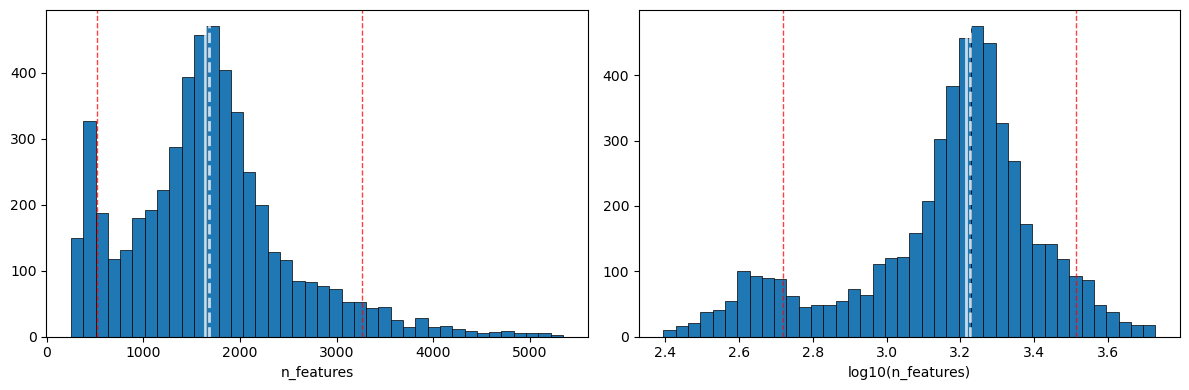

Max:	5342
Median:	1638.0
Mean:	1678.458771762005
Min:	249


In [76]:
epi.pl.histogram(adata, "n_features", min_threshold=min_features, max_threshold=max_features, show_log=True)

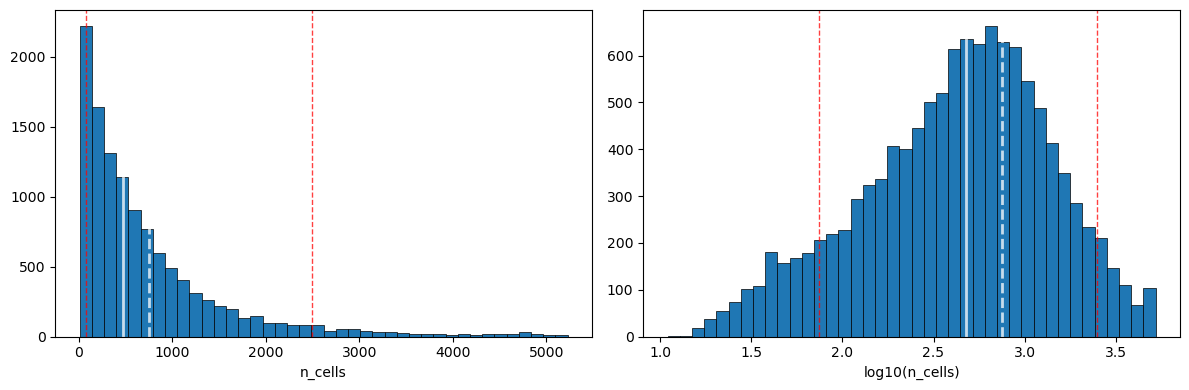

Max:	5227
Median:	476.0
Mean:	749.8550427350427
Min:	11


In [77]:
epi.pl.histogram(adata, "n_cells", min_threshold=min_cells, max_threshold=max_cells, show_log=True)

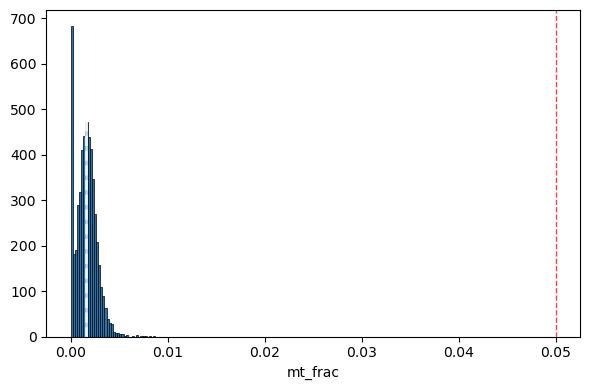

Max:	0.008728179149329662
Median:	0.0015723269898444414
Mean:	0.0015948580112308264
Min:	0.0


In [78]:
epi.pl.histogram(adata, "mt_frac", max_threshold=0.05, show_log=False)

In [79]:
epi.pp.set_filter(adata, "n_features", min_threshold=min_features, max_threshold=max_features, verbose=False)
epi.pp.set_filter(adata, "n_cells", min_threshold=min_cells, max_threshold=max_cells, verbose=False)
adata = epi.pp.apply_filters(adata, verbose=False)
adata = adata[adata.obs["mt_frac"]<=0.05]
adata=adata[adata.obs.predicted_doublet==False]
adata

View of AnnData object with n_obs × n_vars = 4441 × 9942
    obs: 'GEX_n_genes_by_counts', 'GEX_pct_counts_mt', 'GEX_size_factors', 'GEX_phase', 'ADT_n_antibodies_by_counts', 'ADT_total_counts', 'ADT_iso_count', 'cell_type', 'batch', 'ADT_pseudotime_order', 'GEX_pseudotime_order', 'Samplename', 'Site', 'DonorNumber', 'Modality', 'VendorLot', 'DonorID', 'DonorAge', 'DonorBMI', 'DonorBloodType', 'DonorRace', 'Ethnicity', 'DonorGender', 'QCMeds', 'DonorSmoker', 'is_train', 'CellType', 'doublet_score', 'predicted_doublet', 'n_features', 'log_n_features', 'n_counts', 'log_n_counts', 'mt_frac', 'passes_filter'
    var: 'feature_types', 'gene_id', 'n_cells', 'log_n_cells', 'passes_filter'
    uns: 'dataset_id', 'genome', 'organism', 'scrublet'
    obsm: 'ADT_X_pca', 'ADT_X_umap', 'ADT_isotype_controls', 'GEX_X_pca', 'GEX_X_umap'
    layers: 'counts'

In [80]:
sc.pp.highly_variable_genes(adata, flavor='seurat_v3')
min_var = np.quantile(adata.var.variances_norm, 0.6)
adata=adata[:, adata.var.variances_norm>min_var]

In [81]:
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)
adata = adata[:, adata.X.max(axis=0)>0]
adata = adata[adata.X.max(axis=1)>0]
adata

View of AnnData object with n_obs × n_vars = 4441 × 3977
    obs: 'GEX_n_genes_by_counts', 'GEX_pct_counts_mt', 'GEX_size_factors', 'GEX_phase', 'ADT_n_antibodies_by_counts', 'ADT_total_counts', 'ADT_iso_count', 'cell_type', 'batch', 'ADT_pseudotime_order', 'GEX_pseudotime_order', 'Samplename', 'Site', 'DonorNumber', 'Modality', 'VendorLot', 'DonorID', 'DonorAge', 'DonorBMI', 'DonorBloodType', 'DonorRace', 'Ethnicity', 'DonorGender', 'QCMeds', 'DonorSmoker', 'is_train', 'CellType', 'doublet_score', 'predicted_doublet', 'n_features', 'log_n_features', 'n_counts', 'log_n_counts', 'mt_frac', 'passes_filter'
    var: 'feature_types', 'gene_id', 'n_cells', 'log_n_cells', 'passes_filter', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'dataset_id', 'genome', 'organism', 'scrublet', 'hvg', 'log1p'
    obsm: 'ADT_X_pca', 'ADT_X_umap', 'ADT_isotype_controls', 'GEX_X_pca', 'GEX_X_umap'
    layers: 'counts'

In [82]:
adata.write("Datasets/BMMCCite/CM/BMMCCite_mRNA_Def.h5ad", compression="gzip")

## lncRNA

In [8]:
adata=sc.read_h5ad("Datasets/BMMCCite/CM/BMMCCite_lncRNA_Raw.h5ad")
adata.layers["raw"]=scipy.sparse.csr_matrix(adata.X.copy())
del adata.layers["counts"]
adata

AnnData object with n_obs × n_vars = 5227 × 686
    obs: 'GEX_n_genes_by_counts', 'GEX_pct_counts_mt', 'GEX_size_factors', 'GEX_phase', 'ADT_n_antibodies_by_counts', 'ADT_total_counts', 'ADT_iso_count', 'cell_type', 'batch', 'ADT_pseudotime_order', 'GEX_pseudotime_order', 'Samplename', 'Site', 'DonorNumber', 'Modality', 'VendorLot', 'DonorID', 'DonorAge', 'DonorBMI', 'DonorBloodType', 'DonorRace', 'Ethnicity', 'DonorGender', 'QCMeds', 'DonorSmoker', 'is_train', 'CellType', 'doublet_score', 'predicted_doublet'
    var: 'feature_types', 'gene_id'
    uns: 'dataset_id', 'genome', 'organism', 'scrublet'
    obsm: 'ADT_X_pca', 'ADT_X_umap', 'ADT_isotype_controls', 'GEX_X_pca', 'GEX_X_umap'
    layers: 'raw'

In [63]:
epi.pp.qc_stats(adata, verbose=True)

added keys n_cells, log_n_cells to .var
added keys n_features, log_n_features, n_counts, log_n_counts to .obs


In [64]:
min_features = 10**np.quantile(adata.obs["log_n_features"], 0.1)
max_features = 10**np.quantile(adata.obs["log_n_features"], 0.975)
min_cells = 10**np.quantile(adata.var["log_n_cells"], 0.02)
max_cells = 10**np.quantile(adata.var["log_n_cells"], 0.925)

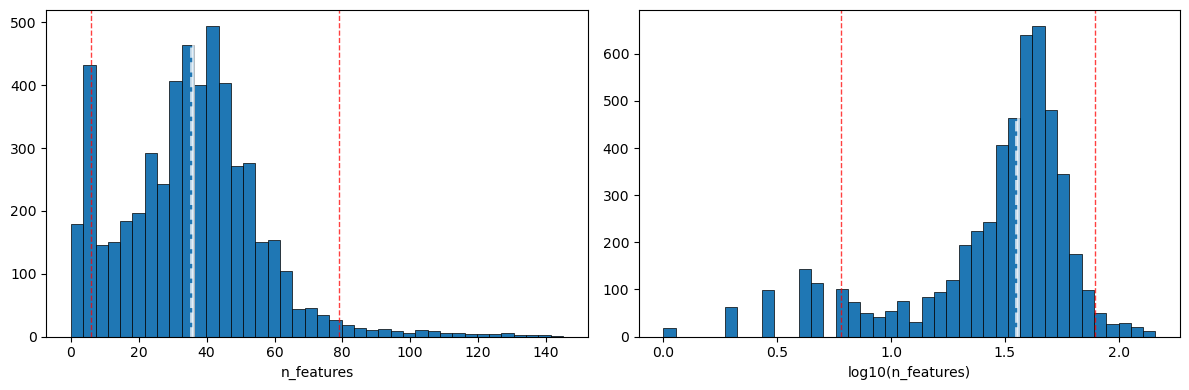

Max:	145
Median:	36.0
Mean:	35.27606657738664
Min:	0


In [65]:
epi.pl.histogram(adata, "n_features", min_threshold=min_features, max_threshold=max_features, show_log=True)

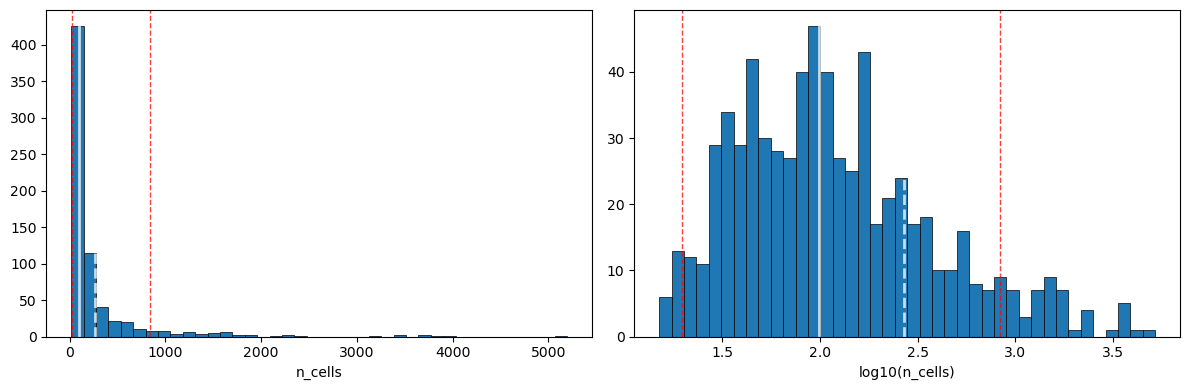

Max:	5196
Median:	99.0
Mean:	268.7871720116618
Min:	15


In [66]:
epi.pl.histogram(adata, "n_cells", min_threshold=min_cells, max_threshold=max_cells, show_log=True)

In [67]:
epi.pp.set_filter(adata, "n_features", min_threshold=min_features, max_threshold=max_features, verbose=False)
epi.pp.set_filter(adata, "n_cells", min_threshold=min_cells, max_threshold=max_cells, verbose=False)
adata = epi.pp.apply_filters(adata, verbose=False)
adata

AnnData object with n_obs × n_vars = 4657 × 620
    obs: 'GEX_n_genes_by_counts', 'GEX_pct_counts_mt', 'GEX_size_factors', 'GEX_phase', 'ADT_n_antibodies_by_counts', 'ADT_total_counts', 'ADT_iso_count', 'cell_type', 'batch', 'ADT_pseudotime_order', 'GEX_pseudotime_order', 'Samplename', 'Site', 'DonorNumber', 'Modality', 'VendorLot', 'DonorID', 'DonorAge', 'DonorBMI', 'DonorBloodType', 'DonorRace', 'Ethnicity', 'DonorGender', 'QCMeds', 'DonorSmoker', 'is_train', 'CellType', 'doublet_score', 'predicted_doublet', 'n_features', 'log_n_features', 'n_counts', 'log_n_counts', 'passes_filter'
    var: 'feature_types', 'gene_id', 'n_cells', 'log_n_cells', 'passes_filter'
    uns: 'dataset_id', 'genome', 'organism', 'scrublet'
    obsm: 'ADT_X_pca', 'ADT_X_umap', 'ADT_isotype_controls', 'GEX_X_pca', 'GEX_X_umap'
    layers: 'counts'

In [68]:
sc.pp.highly_variable_genes(adata, flavor='seurat_v3')
min_var = np.quantile(adata.var.variances_norm, 0.05)
adata=adata[:, adata.var.variances_norm>min_var]

In [69]:
epi.pp.normalize_total(adata)
sc.pp.log1p(adata)
adata = adata[:, adata.X.max(axis=0)>0]
adata = adata[adata.X.max(axis=1)>0]
adata

View of AnnData object with n_obs × n_vars = 4655 × 589
    obs: 'GEX_n_genes_by_counts', 'GEX_pct_counts_mt', 'GEX_size_factors', 'GEX_phase', 'ADT_n_antibodies_by_counts', 'ADT_total_counts', 'ADT_iso_count', 'cell_type', 'batch', 'ADT_pseudotime_order', 'GEX_pseudotime_order', 'Samplename', 'Site', 'DonorNumber', 'Modality', 'VendorLot', 'DonorID', 'DonorAge', 'DonorBMI', 'DonorBloodType', 'DonorRace', 'Ethnicity', 'DonorGender', 'QCMeds', 'DonorSmoker', 'is_train', 'CellType', 'doublet_score', 'predicted_doublet', 'n_features', 'log_n_features', 'n_counts', 'log_n_counts', 'passes_filter'
    var: 'feature_types', 'gene_id', 'n_cells', 'log_n_cells', 'passes_filter', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'dataset_id', 'genome', 'organism', 'scrublet', 'hvg', 'log1p'
    obsm: 'ADT_X_pca', 'ADT_X_umap', 'ADT_isotype_controls', 'GEX_X_pca', 'GEX_X_umap'
    layers: 'counts'

In [70]:
adata.write("Datasets/BMMCCite/CM/BMMCCite_lncRNA_Def.h5ad", compression="gzip")

## ADT

In [9]:
adata=sc.read_h5ad("Datasets/BMMCCite/CM/BMMCCite_ADT_Raw.h5ad")
adata.layers["raw"]=scipy.sparse.csr_matrix(adata.X.copy())
del adata.layers["counts"]
adata.var["highly_variable"]=True
adata

AnnData object with n_obs × n_vars = 5227 × 134
    obs: 'GEX_n_genes_by_counts', 'GEX_pct_counts_mt', 'GEX_size_factors', 'GEX_phase', 'ADT_n_antibodies_by_counts', 'ADT_total_counts', 'ADT_iso_count', 'cell_type', 'batch', 'ADT_pseudotime_order', 'GEX_pseudotime_order', 'Samplename', 'Site', 'DonorNumber', 'Modality', 'VendorLot', 'DonorID', 'DonorAge', 'DonorBMI', 'DonorBloodType', 'DonorRace', 'Ethnicity', 'DonorGender', 'QCMeds', 'DonorSmoker', 'is_train', 'CellType'
    var: 'feature_types', 'gene_id', 'highly_variable'
    uns: 'dataset_id', 'genome', 'organism'
    obsm: 'ADT_X_pca', 'ADT_X_umap', 'ADT_isotype_controls', 'GEX_X_pca', 'GEX_X_umap'
    layers: 'raw'

In [31]:
sc.pp.normalize_total(adata)

In [32]:
sc.pp.log1p(adata)

In [33]:
adata = adata[:, adata.X.max(axis=0)>0]
adata = adata[adata.X.max(axis=1)>0]
adata

View of AnnData object with n_obs × n_vars = 5227 × 134
    obs: 'GEX_n_genes_by_counts', 'GEX_pct_counts_mt', 'GEX_size_factors', 'GEX_phase', 'ADT_n_antibodies_by_counts', 'ADT_total_counts', 'ADT_iso_count', 'cell_type', 'batch', 'ADT_pseudotime_order', 'GEX_pseudotime_order', 'Samplename', 'Site', 'DonorNumber', 'Modality', 'VendorLot', 'DonorID', 'DonorAge', 'DonorBMI', 'DonorBloodType', 'DonorRace', 'Ethnicity', 'DonorGender', 'QCMeds', 'DonorSmoker', 'is_train', 'CellType'
    var: 'feature_types', 'gene_id', 'highly_variable'
    uns: 'dataset_id', 'genome', 'organism', 'log1p'
    obsm: 'ADT_X_pca', 'ADT_X_umap', 'ADT_isotype_controls', 'GEX_X_pca', 'GEX_X_umap'
    layers: 'counts'

In [34]:
adata.write("Datasets/BMMCCite/CM/BMMCCite_ADT_Def.h5ad", compression="gzip")

## Muon objects

In [5]:
import muon as mu
adt=sc.read_h5ad(f"Datasets/BMMCCite/CM/BMMCCite_ADT_Def.h5ad")
gex=sc.read_h5ad(f"Datasets/BMMCCite/CM/BMMCCite_GEX_Def.h5ad")
mrna=sc.read_h5ad(f"Datasets/BMMCCite/CM/BMMCCite_mRNA_Def.h5ad")
lncrna=sc.read_h5ad(f"Datasets/BMMCCite/CM/BMMCCite_lncRNA_Def.h5ad")

#ADT + GEX
print("ADT + GEX")
inter=intersection([adt.obs.index, gex.obs.index])
mudata=mu.MuData({"ADT" : adt[inter], "GEX" : gex[inter]})
mudata.write_h5mu(f"Datasets/BMMCCite/CM/BMMCCite_ADT_GEX_Def.h5mu", compression="gzip")

#ADT + mRNA
print("ADT + mRNA")
inter=intersection([adt.obs.index, mrna.obs.index])
mudata=mu.MuData({"ADT" : adt[inter], "mRNA" : mrna[inter]})
mudata.write_h5mu(f"Datasets/BMMCCite/CM/BMMCCite_ADT_mRNA_Def.h5mu", compression="gzip")

#ADT + lncRNA
print("ADT + lncRNA")
inter=intersection([adt.obs.index, lncrna.obs.index])
mudata=mu.MuData({"ADT" : adt[inter], "lncRNA" : lncrna[inter]})
mudata.write_h5mu(f"Datasets/BMMCCite/CM/BMMCCite_ADT_lncRNA_Def.h5mu", compression="gzip")

#mRNA + lncRNA
print("mRNA + lncRNA")
inter=intersection([mrna.obs.index, lncrna.obs.index])
mudata=mu.MuData({"mRNA" : mrna[inter], "lncRNA" : lncrna[inter]})
mudata.write_h5mu(f"Datasets/BMMCCite/CM/BMMCCite_mRNA_lncRNA_Def.h5mu", compression="gzip")

#ADT + mRNA + lncRNA
print("ADT + mRNA + lncRNA")
inter=intersection([adt.obs.index, mrna.obs.index, lncrna.obs.index])
mudata=mu.MuData({"ADT" : adt[inter], "mRNA" : mrna[inter], "lncRNA" : lncrna[inter]})
mudata.write_h5mu(f"Datasets/BMMCCite/CM/BMMCCite_ADT_mRNA_lncRNA_Def.h5mu", compression="gzip")

ADT + GEX
ADT + mRNA
ADT + lncRNA
mRNA + lncRNA
ADT + mRNA + lncRNA


# CTA

In [2]:
df=sc.read_h5ad("Datasets/BMMCCite/CM/BMMCCite_GEX_Raw.h5ad").obs
df.head()

,GEX_n_genes_by_counts,GEX_pct_counts_mt,GEX_size_factors,GEX_phase,ADT_n_antibodies_by_counts,ADT_total_counts,ADT_iso_count,cell_type,batch,ADT_pseudotime_order,...,DonorBloodType,DonorRace,Ethnicity,DonorGender,QCMeds,DonorSmoker,is_train,CellType,doublet_score,predicted_doublet
GCATTAGCATAAGCGG-1-s1d1,893,6.723979,0.356535,G1,115,2828.0,5.0,Naive CD20+ B IGKC+,s1d1,NaN,...,B-,White,HISPANIC OR LATINO,Male,False,Nonsmoker,train,Naive CD20+ B IGKC+,0.012640,False
TACAGGTGTTAGAGTA-1-s1d1,2606,8.008829,1.292643,S,137,8819.0,21.0,CD14+ Mono,s1d1,NaN,...,B-,White,HISPANIC OR LATINO,Male,False,Nonsmoker,train,CD14+ Mono,0.082126,False
AGGATCTAGGTCTACT-1-s1d1,1867,6.959707,0.970558,G2M,116,4088.0,12.0,Naive CD20+ B IGKC+,s1d1,NaN,...,B-,White,HISPANIC OR LATINO,Male,False,Nonsmoker,train,Naive CD20+ B IGKC+,0.022242,False
GTAGAAAGTGACACAG-1-s1d1,2360,6.109234,1.232604,G2M,124,4447.0,9.0,HSC,s1d1,NaN,...,B-,White,HISPANIC OR LATINO,Male,False,Nonsmoker,train,HSC,0.029544,False
TCCGAAAAGGATCATA-1-s1d1,455,0.294394,0.044585,S,132,12875.0,24.0,Reticulocyte,s1d1,0.735261,...,B-,White,HISPANIC OR LATINO,Male,False,Nonsmoker,train,Reticulocyte,0.015994,False


In [6]:
df[["CellType"]].to_csv("Datasets/BMMCCite/BMMCCite_Metadata.tsv.gz", sep="\t", compression="gzip")